# Импорты

In [1]:
# %pip install matplotlib
# %pip install pymatgen
# %pip install crystal_toolkit

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from pymatgen.core import Structure

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp import Incar

from pymatgen.symmetry.bandstructure import HighSymmKpath
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

from pymatgen.electronic_structure.core import Spin

In [4]:
pd.set_option('display.float_format', '{:.2e}'.format)

In [ ]:
Ni_start_structure = Structure.from_file("Ni/POSCAR")
Al_start_structure = Structure.from_file("Al/POSCAR")
Ni3Al_start_structure = Structure.from_file("Ni3Al/POSCAR")

Ni_Outcar = Outcar("Ni/result/OUTCAR")
Al_Outcar = Outcar("Al/result/OUTCAR")
Ni3Al_Outcar = Outcar("Ni3Al/result/OUTCAR")

Ni_INCAR = Incar.from_file("Ni/INCAR")
Al_INCAR = Incar.from_file("Al/INCAR")
Ni3Al_INCAR = Incar.from_file("Ni3Al/INCAR")

Ni_vasprun = Vasprun("Ni/result/vasprun.xml")
Al_vasprun = Vasprun("Al/result/vasprun.xml")
Ni3Al_vasprun = Vasprun("Ni3Al/result/vasprun.xml")

In [6]:
# run_01 - для сравнения
Ni3Al_01_start_structure = Structure.from_file("Ni3Al/POSCAR")
Ni3Al_01_optimized_structure = Structure.from_file("Ni3Al/result/CONTCAR")
Ni3Al_01_INCAR = Incar.from_file("../run_01/Ni3Al/INCAR")
Ni3Al_01_Outcar = Outcar("../run_01/Ni3Al/result/OUTCAR")
Ni3Al_01_vasprun = Vasprun("../run_01/Ni3Al/result/vasprun.xml")

Ni_01_Outcar = Outcar("../run_01/Ni/result/OUTCAR")
Al_01_Outcar = Outcar("../run_01/Al/result/OUTCAR")
Ni_01_optimized_structure = Structure.from_file("../run_01/Ni/result/CONTCAR")
Al_01_optimized_structure = Structure.from_file("../run_01/Al/result/CONTCAR")
Ni_01_vasprun = Vasprun("../run_01/Ni/result/vasprun.xml")
Al_01_vasprun = Vasprun("../run_01/Al/result/vasprun.xml")

# Параметры расчета

In [7]:
df_incar = pd.DataFrame({
    'Ni': dict(Ni_INCAR),
    'Al': dict(Al_INCAR),
    'Ni3Al (run_03)': dict(Ni3Al_INCAR),
    'Ni3Al (run_01)': dict(Ni3Al_01_INCAR)
}).fillna('')

df_incar

,Ni,Al,Ni3Al (run_03),Ni3Al (run_01)
SYSTEM,Ni bulk fcc,Al bulk fcc,Ni3Al L12,Ni3Al L12
PREC,Accurate,Accurate,Accurate,Accurate
NCORE,4,4,4,4
LREAL,False,False,False,False
LWAVE,False,False,False,False
LASPH,True,True,True,True
ADDGRID,True,True,True,True
KSPACING,1.00e-01,1.00e-01,1.00e-01,1.00e-01
SYMPREC,1.00e-05,1.00e-05,1.00e-05,1.00e-05
ISYM,2,2,2,2


# Проверка сходимости электронного и ионного цикла

In [8]:
pd.set_option('display.float_format', '{:3}'.format)

df_stats = pd.DataFrame([{**outcar.run_stats, 'System': name} for name, outcar in [('Ni', Ni_Outcar), ('Al', Al_Outcar), ('Ni3Al', Ni3Al_Outcar)]])
df_stats

,Average memory used (kb),Maximum memory used (kb),Elapsed time (sec),System time (sec),User time (sec),Total CPU time used (sec),cores,System
0,None,110152.0,132.939,18.598,110.833,129.431,24,Ni
1,None,76992.0,23.776,5.303,17.114,22.418,24,Al
2,None,134672.0,222.649,27.178,188.773,215.951,24,Ni3Al


> Все три расчёта завершились штатно и сошлись, а не остановились из-за ограничения по числу шагов (NSW). Во всех случаях стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) уже были близки к равновесным, поэтому релаксация потребовала лишь двух итераций, и ионы практически не смещались.

## Электронный цикл

In [9]:
Ni_steps = Ni_vasprun.ionic_steps
Al_steps = Al_vasprun.ionic_steps
Ni3Al_steps = Ni3Al_vasprun.ionic_steps

In [10]:
data = []
for name, steps in [('Ni', Ni_steps), ('Al', Al_steps), ('Ni3Al', Ni3Al_steps)]:
    es = steps[-1]['electronic_steps']
    for i in range(1, len(es)):
        d = abs(es[i]['e_fr_energy'] - es[i-1]['e_fr_energy'])
        data.append((name, i, d))

df_delta_e = pd.DataFrame(data, columns=['Система', 'Итерация', '|ΔE| (эВ)'])

df_delta_e.style.hide(axis='index').format({'|ΔE| (эВ)': '{:.10f}'})

Система,Итерация,|ΔE| (эВ)
Ni,1,246.3319304400
Ni,2,8.8501742900
Ni,3,0.0582408000
Ni,4,0.0001419400
Ni,5,2.6856436900
Ni,6,1.2367743400
Ni,7,0.0501916800
Ni,8,0.0146452300
Ni,9,0.0001680400
Ni,10,0.0000161900


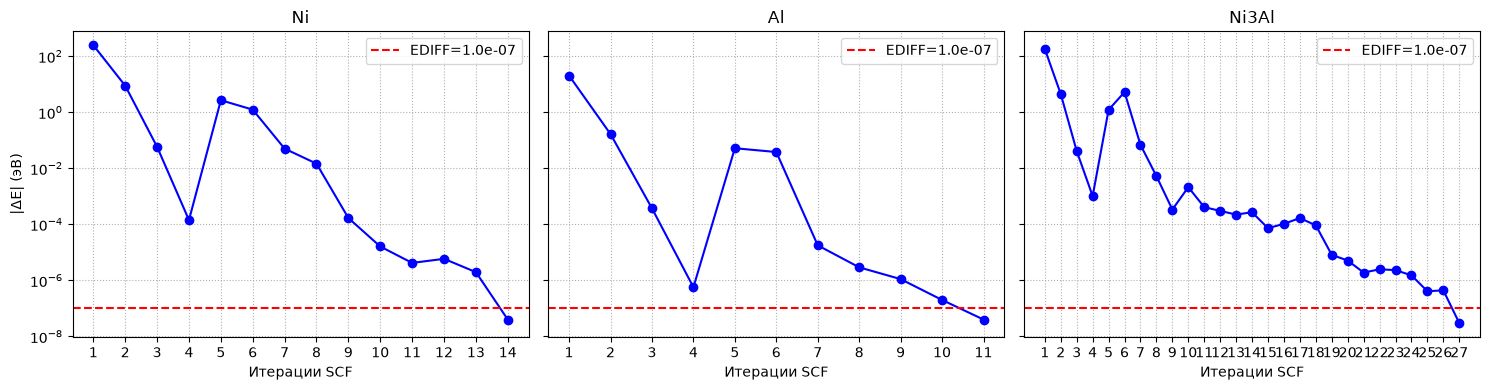

In [11]:
EDIFF = Ni_INCAR.get('EDIFF')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, ['Ni', 'Al', 'Ni3Al']):
    sub = df_delta_e[df_delta_e['Система'] == name]
    ax.plot(sub['Итерация'], sub['|ΔE| (эВ)'], 'o-', color='b')
    ax.axhline(EDIFF, color='r', linestyle='--', label=f'EDIFF={EDIFF:.1e}')
    ax.set_yscale('log')    
    ax.set_xlabel('Итерации SCF')
    ax.set_title(name)
    ax.grid(linestyle=':')
    ax.legend()
    max_iter = sub['Итерация'].max()
    ax.set_xticks(range(1, max_iter + 1))

axes[0].set_ylabel('|ΔE| (эВ)')
plt.tight_layout()
plt.show()

## Ионный цикл

In [12]:
data_ion_forces = []
for name, steps in [('Ni', Ni_steps), ('Al', Al_steps), ('Ni3Al', Ni3Al_steps)]:
    for i, step in enumerate(steps):
        forces = step['forces']
        max_force = max(abs(f) for atom in forces for f in atom)
        data_ion_forces.append({'Система': name, 'Ионный шаг': i, '|F_max| (эВ/Å)': max_force})

df_ion_forces = pd.DataFrame(data_ion_forces)
df_ion_forces

,Система,Ионный шаг,|F_max| (эВ/Å)
0,Ni,0,0.0
1,Al,0,0.0
2,Ni3Al,0,0.0


> **Примечание по ионной сходимости**     
> Для run_03 (ISIF=2) был выполнен только начальный SCF-расчёт (шаг 0), релаксация фактически не запускалась (или завершилась сразу, поскольку силы нулевые).

# Кристаллографические парамеры

In [13]:
# Начальный параметр решетки
Ni_a = Ni_start_structure.lattice.a
Al_a = Al_start_structure.lattice.a
Ni3Al_a = Ni3Al_start_structure.lattice.a

# Начальный объем
Ni_volume = Ni_start_structure.volume
Al_volume = Al_start_structure.volume
Ni3Al_volume = Ni3Al_start_structure.volume

# Пространственная группа
Ni_Space_Group = SpacegroupAnalyzer(Ni_start_structure, 0.1).get_space_group_symbol()
Al_Space_Group = SpacegroupAnalyzer(Al_start_structure, 0.1).get_space_group_symbol()
Ni3Al_Space_Group = SpacegroupAnalyzer(Ni3Al_start_structure, 0.1).get_space_group_symbol()


In [14]:
# Параметры решётки из run_01
Ni_a_opt_01 = Ni_01_optimized_structure.lattice.a
Al_a_opt_01 = Al_01_optimized_structure.lattice.a
Ni3Al_a_opt_01 = Ni3Al_01_optimized_structure.lattice.a

# Объем из run_01
Ni_volume_01 = Ni_01_optimized_structure.volume
Al_volume_01 = Al_01_optimized_structure.volume
Ni3Al_volume_01 = Ni3Al_01_optimized_structure.volume

In [15]:
pd.set_option('display.float_format', '{:.6f}'.format)

data_crystal = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'Группа': [Ni_Space_Group, Al_Space_Group, Ni3Al_Space_Group],
    'a старт. (Å)': [Ni_a, Al_a, Ni3Al_a],
    '(run_01) a опт. (Å)': [Ni_a_opt_01, Al_a_opt_01, Ni3Al_a_opt_01],
    'V старт. (Å³)': [Ni_volume, Al_volume, Ni3Al_volume],
    '(run_01) V опт. (Å³)': [Ni_volume_01, Al_volume_01, Ni3Al_volume_01],
}

df_crystal = pd.DataFrame(data_crystal)
df_crystal

,Система,Группа,a старт. (Å),(run_01) a опт. (Å),V старт. (Å³),(run_01) V опт. (Å³)
0,Ni,Fm-3m,3.520000,3.523755,43.614208,43.753931
1,Al,Fm-3m,4.050000,4.038652,66.430125,65.873284
2,Ni3Al,Pm-3m,3.570000,3.570000,45.499293,45.499293


# Магнитный момент

In [16]:
Al_total_mag = Al_Outcar.total_mag
Al_total_mag # None

In [17]:
Ni_total_mag = Ni_Outcar.total_mag
print("Ni:", Ni_total_mag, "μ_B")

Ni: 2.504001 μ_B



**из INCAR для Ni:**
```VASP
ISPIN=2
MAGMOM=4*0.6
```

Получив для чистого никеля `total_mag = 2.5077 µ_B` (при стартовом `MAGMOM = 4×0.6 = 2.4 µ_B`), можно заключить, что система не только сохранила заданную намагниченность, но и увеличила её за счёт обменного взаимодействия. Финальное значение близко к экспериментальному (∼0.6 µ_B на атом Ni - [DOI:10.1103/PhysRev.138.A755](https://journals.aps.org/pr/abstract/10.1103/PhysRev.138.A755)), что подтверждает устойчивость ферромагнитного состояния в чистом Ni.

In [18]:
Ni3Al_total_mag = Ni3Al_Outcar.total_mag
print("Ni3Al:", Ni3Al_total_mag, "μ_B")

Ni3Al: 0.0011988 μ_B


**из INCAR для Ni3Al:**
```VASP
ISPIN=2
MAGMOM-0.0 3*0.2
```

Несмотря на то, что в INCAR был задан ISPIN=2 и начальные магнитные моменты `MAGMOM = 0.0 3*0.2` (для каждого атома Ni – 0.2 $μ_B$), итоговая суммарная намагниченность системы оказалась практически равной нулю (0.00015 µ_B). Это свидетельствует о том, что спонтанная спиновая поляризация в данной структуре отсутствует – расчёт привёл к немагнитному состоянию.

Такое поведение согласуется с литературными данными ([DOI:10.1016/j.intermet.2006.08.010](https://www.sciencedirect.com/science/article/abs/pii/S0966979506002548?via%3Dihub)) для объёмного Ni₃Al со структурой L1₂ – он действительно является слабомагнитным или парамагнитным при комнатных условиях.

In [19]:
Ni3Al_Outcar.magnetization

({'s': 0.0, 'p': -0.0, 'd': 0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': 0.001, 'tot': 0.001},
 {'s': -0.0, 'p': -0.0, 'd': 0.001, 'tot': 0.001},
 {'s': -0.0, 'p': -0.0, 'd': 0.001, 'tot': 0.001})

> Все значения практически равны нулю. Это означает, что на атомах Ni и Al не возникает спонтанной спиновой поляризации – локальные магнитные моменты отсутствуют.
>
> Важно отметить, что сумма локальных моментов не обязана в точности равняться полному моменту, поскольку локальные моменты интегрируются только внутри сфер радиуса `RWIGS`, а часть спиновой плотности может находиться в межатомных областях. Однако в данном случае обе величины практически нулевые, что подтверждает немагнитный характер системы.
>
> Таким образом, добавление `LORBIT = 11` позволило убедиться в отсутствии локальных магнитных моментов в системе Ni₃Al.

P.S. отрицательные нули `-0.0` являются артефактами округления с плавающей точкой

# Полные энергии и энтальпия образования Ni3Al

In [20]:
# Полные энергии
TOTEN_Ni = Ni_Outcar.final_energy
TOTEN_Al = Al_Outcar.final_energy
TOTEN_Ni3Al = Ni3Al_Outcar.final_energy

print("Ni:", TOTEN_Ni, "эВ")
print("Al:", TOTEN_Al, "эВ")
print("Ni3Al:", TOTEN_Ni3Al, "эВ")

Ni: -22.2895925 эВ
Al: -14.98398113 эВ
Ni3Al: -22.19658512 эВ


In [21]:
# Изменение энтальпии образования, выраженное в электрон-вольтах на одну формульную единицу
dH_form_ev_per_fu = TOTEN_Ni3Al - (0.75*TOTEN_Ni+0.25*TOTEN_Al)

# Изменение энтальпии образования, выраженное в килоджоулях на моль формульных единиц
dH_form_kJ_per_mol_fu = dH_form_ev_per_fu*96.485

# Изменение энтальпии образования, выраженное в килоджоулях на моль атомов
dH_form_kJ_per_mol_atom = dH_form_kJ_per_mol_fu / 4

print(dH_form_ev_per_fu, "эВ")
print(dH_form_kJ_per_mol_fu, "кДж/моль формульных единиц")
print(dH_form_kJ_per_mol_atom, "кДж/моль атомов")

-1.733395462499999 эВ
-167.2466611993124 кДж/моль формульных единиц
-41.8116652998281 кДж/моль атомов


# K-точки

In [ ]:
# Кол-во K-точек
Ni_N_KPOINTS = len(Ni_vasprun.actual_kpoints)
Al_N_KPOINTS = len(Al_vasprun.actual_kpoints)
Ni3Al_N_KPOINTS = len(Ni3Al_vasprun.actual_kpoints)

# Координаты первой k-точки по направлению
Ni_kx, Ni_ky, Ni_kz = Ni_vasprun.kpoints.kpts[0]
Al_kx, Al_ky, Al_kz = Al_vasprun.kpoints.kpts[0]
Ni3Al_kx, Ni3Al_ky, Ni3Al_kz = Ni3Al_vasprun.kpoints.kpts[0]

# K-cетка
Ni_kmesh = f"{Ni_kx}×{Ni_ky}×{Ni_kz}"
Al_kmesh = f"{Al_kx}×{Al_ky}×{Al_kz}"
Ni3Al_kmesh = f"{Ni3Al_kx}×{Ni3Al_ky}×{Ni3Al_kz}"

# K-точки высокой симметрии
Ni_hs_points = ', '.join(HighSymmKpath(Ni_start_structure).kpath['kpoints'].keys())
Al_hs_points = ', '.join(HighSymmKpath(Al_start_structure).kpath['kpoints'].keys())
Ni3Al_hs_points = ', '.join(HighSymmKpath(Ni3Al_start_structure).kpath['kpoints'].keys())

In [23]:
data_kpoints = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'N k-точек': [Ni_N_KPOINTS, Al_N_KPOINTS, Ni3Al_N_KPOINTS],
    'K-меш': [Ni_kmesh, Al_kmesh, Ni3Al_kmesh],
    'Высокосимм. точки': [Ni_hs_points, Al_hs_points, Ni3Al_hs_points],
}

df_kpoints = pd.DataFrame(data_kpoints)
df_kpoints

,Система,N k-точек,K-меш,Высокосимм. точки
0,Ni,220,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,165,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,220,18×18×18,"\Gamma, X, R, M"


# Плотность состояний (DOS)

In [24]:
Ni_complete_dos = Ni_vasprun.complete_dos
Al_complete_dos = Al_vasprun.complete_dos
Ni3Al_complete_dos = Ni3Al_vasprun.complete_dos

Ni_complete_dos_energy = Ni_complete_dos.energies
Al_complete_dos_energy = Al_complete_dos.energies
Ni3Al_complete_dos_energy = Ni3Al_complete_dos.energies

Ni_complete_dos_densities = sum(Ni_complete_dos.densities.values())
Al_complete_dos_densities = sum(Al_complete_dos.densities.values())
Ni3Al_complete_dos_densities = sum(Ni3Al_complete_dos.densities.values())

Ni_efermi = Ni_Outcar.efermi
Al_efermi = Al_Outcar.efermi
Ni3Al_efermi = Ni3Al_Outcar.efermi

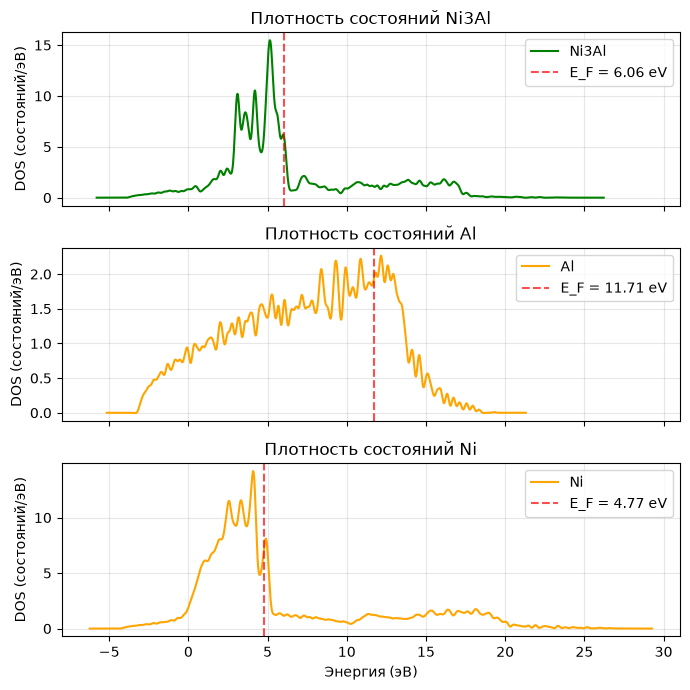

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Ni3Al
axes[0].plot(Ni3Al_complete_dos_energy, Ni3Al_complete_dos_densities, color='green', label='Ni3Al')
axes[0].axvline(Ni3Al_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Ni3Al_efermi:.2f} eV')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Плотность состояний Ni3Al')

# Al
axes[1].plot(Al_complete_dos_energy, Al_complete_dos_densities, color='orange', label='Al')
axes[1].axvline(Al_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Al_efermi:.2f} eV')
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Плотность состояний Al')

# Ni
axes[2].plot(Ni_complete_dos_energy, Ni_complete_dos_densities, color='orange', label='Ni')
axes[2].axvline(Ni_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Ni_efermi:.2f} eV')
axes[2].set_xlabel('Энергия (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_title('Плотность состояний Ni')

plt.tight_layout()
plt.show()

## Проектированный DOS (LORBIT=11)

In [26]:
Ni_r3_pdos_element_dos = Ni_vasprun.complete_dos.get_element_dos()
Al_r3_pdos_element_dos = Al_vasprun.complete_dos.get_element_dos()
Ni3Al_r3_pdos_element_dos = Ni3Al_vasprun.complete_dos.get_element_dos()

Ni3Al_r3_elements = list(Ni3Al_r3_pdos_element_dos.keys())
print("Ni3Al элементы:", Ni3Al_r3_elements)

Ni3Al_r3_pdos_Al = Ni3Al_r3_pdos_element_dos[Ni3Al_r3_elements[0]]
Ni3Al_r3_pdos_Ni = Ni3Al_r3_pdos_element_dos[Ni3Al_r3_elements[1]]

Ni3Al элементы: [Element Al, Element Ni]


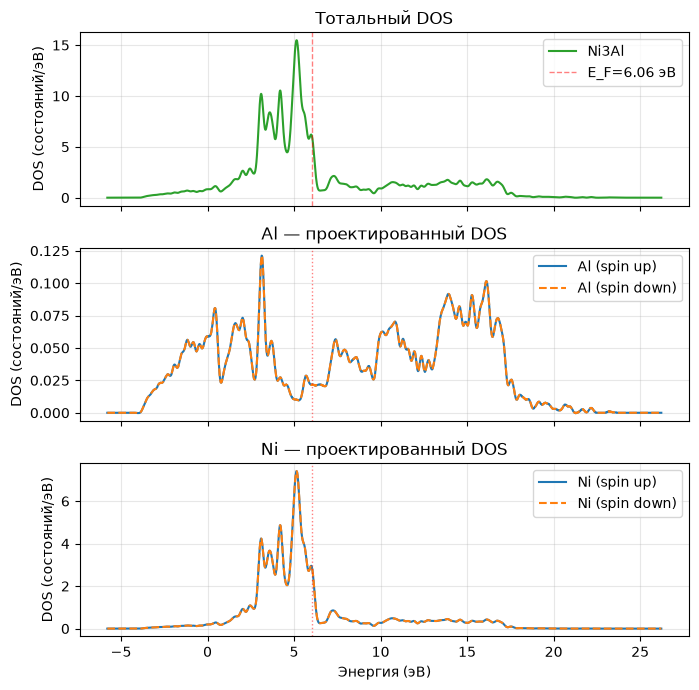

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Тотальный DOS Ni3Al
axes[0].plot(Ni3Al_complete_dos_energy, Ni3Al_complete_dos_densities, label='Ni3Al', color='tab:green')
axes[0].axvline(Ni3Al_efermi, color='r', linestyle='--', alpha=0.5, linewidth=1, label=f'E_F={Ni3Al_efermi:.2f} эВ')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].set_title('Тотальный DOS')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Al
for spin, ls in [(Spin.up, '-'), (Spin.down, '--')]:
    densities = Ni3Al_r3_pdos_Al.get_densities(spin)
    energies = Ni3Al_r3_pdos_Al.energies
    axes[1].plot(energies, densities, ls, label=f'Al (spin {spin.name})', linewidth=1.5)

axes[1].axvline(Ni3Al_efermi, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].set_title('Al — проектированный DOS')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Ni
for spin, ls in [(Spin.up, '-'), (Spin.down, '--')]:
    densities = Ni3Al_r3_pdos_Ni.get_densities(spin)
    energies = Ni3Al_r3_pdos_Ni.energies
    axes[2].plot(energies, densities, ls, label=f'Ni (spin {spin.name})', linewidth=1.5)

axes[2].axvline(Ni3Al_efermi, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[2].set_xlabel('Энергия (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].set_title('Ni — проектированный DOS')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Сводная таблица

In [28]:
df_run1 = pd.DataFrame([
    {'Система': 'Ni', 'E_F (эВ)': Ni_efermi, 'Магн. момент (μB)': Ni_total_mag, 'Полная энергия (эВ)': TOTEN_Ni},
    {'Система': 'Al', 'E_F (эВ)': Al_efermi, 'Магн. момент (μB)': Al_total_mag, 'Полная энергия (эВ)': TOTEN_Al},
    {'Система': 'Ni3Al', 'E_F (эВ)': Ni3Al_efermi, 'Магн. момент (μB)': Ni3Al_total_mag, 'Полная энергия (эВ)': TOTEN_Ni3Al},
])

df_run1 = df_run1.merge(df_crystal)
df_run1 = df_run1.merge(df_kpoints)
df_run1

,Система,E_F (эВ),Магн. момент (μB),Полная энергия (эВ),Группа,a старт. (Å),(run_01) a опт. (Å),V старт. (Å³),(run_01) V опт. (Å³),N k-точек,K-меш,Высокосимм. точки
0,Ni,4.773000,2.504001,-22.289593,Fm-3m,3.520000,3.523755,43.614208,43.753931,220,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,11.706700,NaN,-14.983981,Fm-3m,4.050000,4.038652,66.430125,65.873284,165,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,6.062900,0.001199,-22.196585,Pm-3m,3.570000,3.570000,45.499293,45.499293,220,18×18×18,"\Gamma, X, R, M"


# Сравнение ISIF=2 (run_03) и ISIF=3 (run_01)

In [29]:
# Полные энергии из run_01
TOTEN_Ni_01 = Ni_01_Outcar.final_energy
TOTEN_Al_01 = Al_01_Outcar.final_energy
TOTEN_Ni3Al_01 = Ni3Al_01_Outcar.final_energy

# Магнитные моменты из run_01
Ni_mag_01 = Ni_01_Outcar.total_mag
Al_mag_01 = Al_01_Outcar.total_mag   # будет None
Ni3Al_mag_01 = Ni3Al_01_Outcar.total_mag

# Энергии Ферми из run_01
Ni_ef_01 = Ni_01_Outcar.efermi
Al_ef_01 = Al_01_Outcar.efermi
Ni3Al_ef_01 = Ni3Al_01_Outcar.efermi

In [30]:
comparison_data = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'E (run_01)': [TOTEN_Ni_01, TOTEN_Al_01, TOTEN_Ni3Al_01],
    'E (run_03)': [TOTEN_Ni, TOTEN_Al, TOTEN_Ni3Al],
    'ΔE (эВ)': [TOTEN_Ni_01 - TOTEN_Ni, TOTEN_Al_01 - TOTEN_Al, TOTEN_Ni3Al_01 - TOTEN_Ni3Al],
    'E_F (run_01) (эВ)': [Ni_ef_01, Al_ef_01, Ni3Al_ef_01],
    'E_F (run_03) (эВ)': [Ni_efermi, Al_efermi, Ni3Al_efermi],
    '(run_01) a опт. (Å)': [Ni_a_opt_01, Al_a_opt_01, Ni3Al_a_opt_01],
    '(run_03) a старт. (Å)': [Ni_a, Al_a, Ni3Al_a],
    'Δa (Å)': [Ni_a_opt_01 - Ni_a, Al_a_opt_01 - Al_a, Ni3Al_a_opt_01 - Ni3Al_a],
    'Магн. момент (run_01)': [Ni_mag_01, Al_mag_01, Ni3Al_mag_01],
    'Магн. момент (run_03)': [Ni_total_mag, Al_total_mag, Ni3Al_total_mag],
    'ΔM (μB)': [Ni_mag_01 - Ni_total_mag, 0 , Ni3Al_mag_01 - Ni3Al_total_mag],
}
df_compare = pd.DataFrame(comparison_data)
df_compare

,Система,E (run_01),E (run_03),ΔE (эВ),E_F (run_01) (эВ),E_F (run_03) (эВ),(run_01) a опт. (Å),(run_03) a старт. (Å),Δa (Å),Магн. момент (run_01),Магн. момент (run_03),ΔM (μB)
0,Ni,-22.289853,-22.289593,-0.000261,4.742700,4.773000,3.523755,3.520000,0.003755,2.507740,2.504001,0.003739
1,Al,-14.985164,-14.983981,-0.001183,7.939200,11.706700,4.038652,4.050000,-0.011348,NaN,NaN,0.000000
2,Ni3Al,-22.196603,-22.196585,-0.000018,6.072200,6.062900,3.570000,3.570000,0.000000,0.000154,0.001199,-0.001045


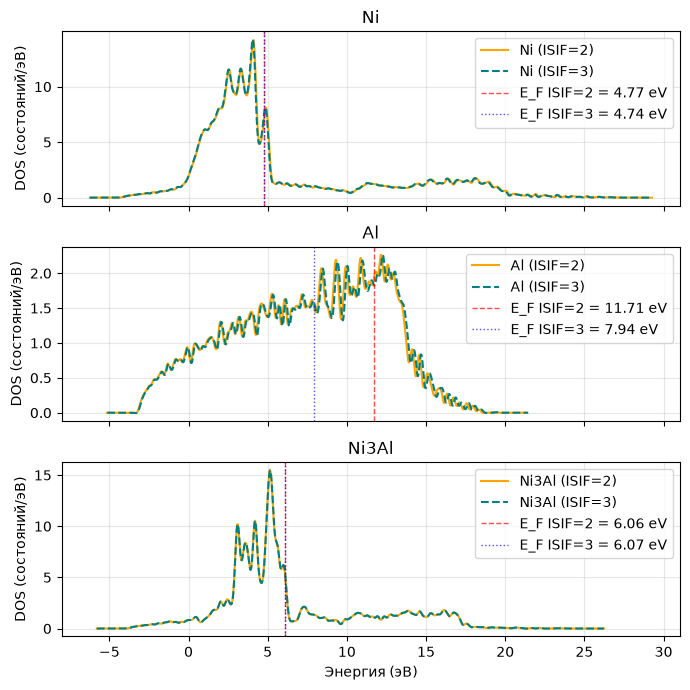

In [31]:
run03 = [(Ni_vasprun, Ni_efermi, 'Ni', 'orange'),
         (Al_vasprun, Al_efermi, 'Al', 'orange'),
         (Ni3Al_vasprun, Ni3Al_efermi, 'Ni3Al', 'orange')]

run01 = [(Ni_01_vasprun, Ni_ef_01, 'Ni'),
         (Al_01_vasprun, Al_ef_01, 'Al'),
         (Ni3Al_01_vasprun, Ni3Al_ef_01, 'Ni3Al')]

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

for i, ((v03, ef03, label, color), (v01, ef01, _)) in enumerate(zip(run03, run01)):
    dos03 = sum(v03.complete_dos.densities.values())
    dos01 = sum(v01.complete_dos.densities.values())
    axes[i].plot(v03.complete_dos.energies, dos03, color=color, label=f'{label} (ISIF=2)')
    axes[i].plot(v01.complete_dos.energies, dos01, color='teal', linestyle='--', label=f'{label} (ISIF=3)')
    axes[i].axvline(ef03, color='r', linestyle='--', alpha=0.7, linewidth=1, label=f'E_F ISIF=2 = {ef03:.2f} eV')
    axes[i].axvline(ef01, color='b', linestyle=':', alpha=0.7, linewidth=1, label=f'E_F ISIF=3 = {ef01:.2f} eV')
    axes[i].set_ylabel('DOS (состояний/эВ)')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].set_title(label)

axes[2].set_xlabel('Энергия (эВ)')
plt.tight_layout()
plt.show()